<a href="https://colab.research.google.com/github/aeshikaz/ML-lab/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

# Load dataset
url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

# Display first few records
print("First 5 records:")
print(df.head())

# Identify column types
print("\nNumerical Columns:", df.select_dtypes(include='number').columns.tolist())
print("Categorical Columns:", df.select_dtypes(include='object').columns.tolist())

# Select numerical features for analysis
num_df = df[['math score', 'reading score', 'writing score']]

# ── Measures of Central Tendency ──
print("\n--- Measures of Central Tendency ---")
print("\nMean:")
print(num_df.mean())

print("\nMedian:")
print(num_df.median())

print("\nMode:")
print(num_df.mode().iloc[0])

# ── Measures of Dispersion ──
print("\n--- Measures of Dispersion ---")
print("\nMinimum:")
print(num_df.min())

print("\nMaximum:")
print(num_df.max())

print("\nSum:")
print(num_df.sum())

print("\nVariance:")
print(num_df.var())

print("\nStandard Deviation:")
print(num_df.std())

First 5 records:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Numerical Columns: ['math score', 'reading score', 'writing score']
Categorical Columns: ['gender', 'race/ethnicity', 'parental level of educ

In [2]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

num_df = df[['math score', 'reading score', 'writing score']]

print("--- Quartile Analysis ---\n")

for col in num_df.columns:
    Q1 = num_df[col].quantile(0.25)
    Q2 = num_df[col].quantile(0.50)
    Q3 = num_df[col].quantile(0.75)
    IQR = Q3 - Q1

    print(f"{col}:")
    print(f"  Q1 (25th percentile) : {Q1}")
    print(f"  Q2 (Median)          : {Q2}")
    print(f"  Q3 (75th percentile) : {Q3}")
    print(f"  IQR (Q3 - Q1)        : {IQR}")
    print()

print("""
Interpretation:
- Q1 : 25% of students scored below this value
- Q2 : The middle value — half scored above, half below
- Q3 : 75% of students scored below this value
- IQR: Spread of the middle 50% of scores; larger IQR means more variability
""")

--- Quartile Analysis ---

math score:
  Q1 (25th percentile) : 57.0
  Q2 (Median)          : 66.0
  Q3 (75th percentile) : 77.0
  IQR (Q3 - Q1)        : 20.0

reading score:
  Q1 (25th percentile) : 59.0
  Q2 (Median)          : 70.0
  Q3 (75th percentile) : 79.0
  IQR (Q3 - Q1)        : 20.0

writing score:
  Q1 (25th percentile) : 57.75
  Q2 (Median)          : 69.0
  Q3 (75th percentile) : 79.0
  IQR (Q3 - Q1)        : 21.25


Interpretation:
- Q1 : 25% of students scored below this value
- Q2 : The middle value — half scored above, half below
- Q3 : 75% of students scored below this value
- IQR: Spread of the middle 50% of scores; larger IQR means more variability



--- Correlation Matrix ---
               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000

Interpretation:
- Values range from -1 to +1
- Close to +1 : Strong positive relationship (both increase together)
- Close to -1 : Strong negative relationship (one increases, other decreases)
- Close to  0 : Little to no linear relationship



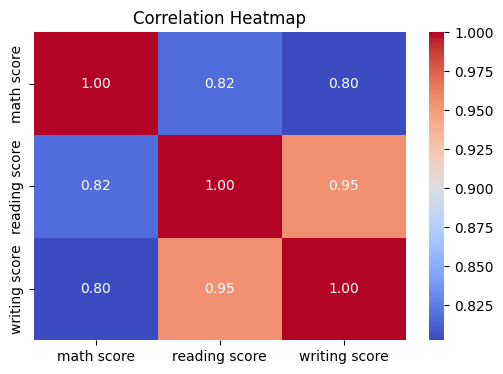

--- Covariance Matrix ---
               math score  reading score  writing score
math score     229.918998     180.998958     184.939133
reading score  180.998958     213.165605     211.786661
writing score  184.939133     211.786661     230.907992

Interpretation:
- Covariance shows the direction of the relationship (positive or negative)
- Unlike correlation, it is NOT normalized so values depend on the scale of data
- Correlation is preferred for comparing relationships across different variables
  because it is scale-independent (always between -1 and +1)



In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

num_df = df[['math score', 'reading score', 'writing score']]

# ── Correlation ──
print("--- Correlation Matrix ---")
corr_matrix = num_df.corr()
print(corr_matrix)

print("""
Interpretation:
- Values range from -1 to +1
- Close to +1 : Strong positive relationship (both increase together)
- Close to -1 : Strong negative relationship (one increases, other decreases)
- Close to  0 : Little to no linear relationship
""")

# Heatmap for correlation
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# ── Covariance ──
print("--- Covariance Matrix ---")
cov_matrix = num_df.cov()
print(cov_matrix)

print("""
Interpretation:
- Covariance shows the direction of the relationship (positive or negative)
- Unlike correlation, it is NOT normalized so values depend on the scale of data
- Correlation is preferred for comparing relationships across different variables
  because it is scale-independent (always between -1 and +1)
""")

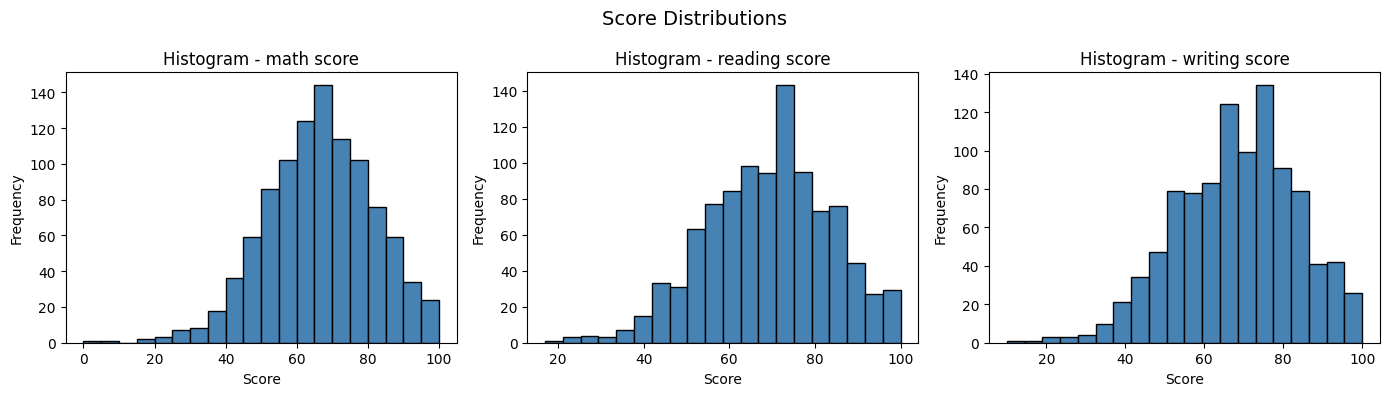

Skewness:
  math score: -0.2789 → skewed left (negative)
  reading score: -0.2591 → skewed left (negative)
  writing score: -0.2894 → skewed left (negative)

Interpretation:
- Skewness near 0   : Symmetric / normal distribution
- Positive skewness : Tail extends to the right (few high scorers)
- Negative skewness : Tail extends to the left (few low scorers)



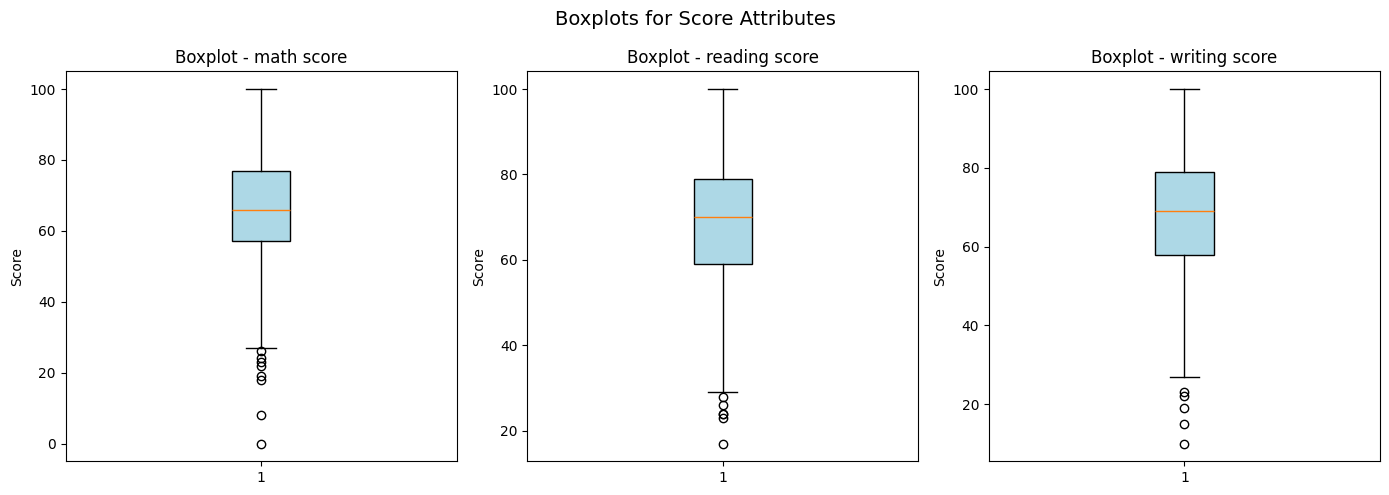


Interpretation:
- The box represents the IQR (Q1 to Q3)
- The line inside the box is the median (Q2)
- Whiskers extend to 1.5 * IQR from Q1 and Q3
- Points beyond whiskers are potential outliers



In [4]:
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

num_df = df[['math score', 'reading score', 'writing score']]

# ── Histograms ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(num_df.columns):
    axes[i].hist(num_df[col], bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(f"Histogram - {col}")
    axes[i].set_xlabel("Score")
    axes[i].set_ylabel("Frequency")

plt.suptitle("Score Distributions", fontsize=14)
plt.tight_layout()
plt.show()

# Print skewness
print("Skewness:")
for col in num_df.columns:
    skew = num_df[col].skew()
    direction = "left (negative)" if skew < 0 else "right (positive)" if skew > 0 else "symmetric"
    print(f"  {col}: {skew:.4f} → skewed {direction}")

print("""
Interpretation:
- Skewness near 0   : Symmetric / normal distribution
- Positive skewness : Tail extends to the right (few high scorers)
- Negative skewness : Tail extends to the left (few low scorers)
""")

# ── Boxplots ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(num_df.columns):
    axes[i].boxplot(num_df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(f"Boxplot - {col}")
    axes[i].set_ylabel("Score")

plt.suptitle("Boxplots for Score Attributes", fontsize=14)
plt.tight_layout()
plt.show()

print("""
Interpretation:
- The box represents the IQR (Q1 to Q3)
- The line inside the box is the median (Q2)
- Whiskers extend to 1.5 * IQR from Q1 and Q3
- Points beyond whiskers are potential outliers
""")